<a href="https://colab.research.google.com/github/nomi181472/pose-estimation-opensource-models/blob/main/movenet_multipose_int8_tflite_ncnn_onnx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MoveNet MultiPose Lightning: LiteRT (TFLite) INT8 + FP16, NCNN FP16

**Pipeline**
1. Download from the HF bucket (`nouman/movenet-multipose-lightning-bucket`): `model.onnx` (FP32 source) and `model_int8.onnx` (diagnosis only)
2. Test FP32 ONNX on your image URLs → annotate → visualize
3. Convert ONNX → **LiteRT/TFLite INT8** and **TFLite FP16** (`onnx2tf`, full model incl. post-processing)
4. Convert ONNX → **NCNN FP16** (`pnnx`). NCNN cannot run the model's built-in post-processing (it has no `Less`/`TopK`/`Where`-style layers: that is the `torch.lt ... not exists` error), so the graph is **split automatically**: backbone → NCNN, post-processing → separate `tail.onnx`
5. Load all converted models, test again → annotate → visualize side by side

## 1. Install

In [ ]:
!pip install -q onnx onnxruntime onnxsim ncnn pnnx opencv-python-headless requests matplotlib huggingface_hub
!pip install -q onnx2tf onnx_graphsurgeon sng4onnx ai-edge-litert tf_keras psutil
# If pip prints a numpy / protobuf conflict: Runtime -> Restart session, then run again from the next cell.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.8/28.8 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 5.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.2 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is in

## 2. Config + imports

In [ ]:
from __future__ import annotations

import shutil
import subprocess
import sys
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Optional, Protocol, Sequence

import cv2
import matplotlib.pyplot as plt
import numpy as np
import requests

# ----------------------------- EDIT HERE -----------------------------
IMAGE_URLS: list[str] = [
    "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/bus.jpg",
    "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/zidane.jpg",
    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/messi5.jpg",
]
INPUT_SIZE: int = 256          # MoveNet multipose-lightning is meant for 256 (multiple of 32)
SCORE_THRESH: float = 0.25     # minimum person score
KP_THRESH: float = 0.20        # minimum keypoint score to draw
HF_TOKEN: Optional[str] = None # only needed if the bucket is private
# ---------------------------------------------------------------------

BUCKET_BASE = "https://huggingface.co/buckets/nouman/movenet-multipose-lightning-bucket/resolve/onnx"
N_CALIB: int = 48              # calibration samples for INT8 (made from your images + augmentations)

WORK = Path("movenet_work")
MODELS = WORK / "models"
OUT = WORK / "outputs"
for d in (MODELS, OUT):
    d.mkdir(parents=True, exist_ok=True)

KEYPOINT_NAMES: list[str] = [
    "nose", "left_eye", "right_eye", "left_ear", "right_ear",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_ankle", "right_ankle",
]
SKELETON: list[tuple[int, int]] = [
    (0, 1), (0, 2), (1, 3), (2, 4), (0, 5), (0, 6), (5, 7), (7, 9), (6, 8), (8, 10),
    (5, 6), (5, 11), (6, 12), (11, 12), (11, 13), (13, 15), (12, 14), (14, 16),
]
PALETTE: list[tuple[int, int, int]] = [  # RGB
    (255, 99, 71), (65, 105, 225), (60, 179, 113), (255, 165, 0), (186, 85, 211),
    (0, 191, 255), (220, 20, 60), (154, 205, 50),
]
print("python", sys.version.split()[0], "| images:", len(IMAGE_URLS))

python 3.13.15 | images: 3


## 3. Types, pre/post-processing, annotation function

In [ ]:
@dataclass(frozen=True)
class Keypoint:
    name: str
    x: float       # pixels in the ORIGINAL image
    y: float
    score: float


@dataclass(frozen=True)
class Pose:
    keypoints: list[Keypoint]
    box: tuple[float, float, float, float]   # x1, y1, x2, y2 in original pixels
    score: float


@dataclass(frozen=True)
class LetterboxInfo:
    scale: float
    orig_w: int
    orig_h: int
    size: int


@dataclass
class Result:
    backend: str
    image_idx: int
    poses: list[Pose]
    latency_ms: float
    annotated: np.ndarray


class PoseRunner(Protocol):
    def infer(self, x: np.ndarray) -> np.ndarray:
        """x: float32 (1, S, S, 3) with RGB values 0..255 -> raw model output."""
        ...


def load_image(url: str) -> np.ndarray:
    """Download an image and return it as an RGB uint8 array."""
    r = requests.get(url, timeout=30, headers={"User-Agent": "Mozilla/5.0"})
    r.raise_for_status()
    bgr = cv2.imdecode(np.frombuffer(r.content, np.uint8), cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError("not a decodable image")
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def load_images(urls: Sequence[str]) -> list[np.ndarray]:
    images: list[np.ndarray] = []
    for u in urls:
        try:
            images.append(load_image(u))
        except Exception as e:  # keep going with the images that work
            print(f"[skip] {u}\n       {type(e).__name__}: {e}")
    if len(images) < 3:
        print(f"WARNING: only {len(images)} usable image(s); add more URLs for a proper test.")
    if not images:
        raise RuntimeError("No images could be loaded.")
    return images


def letterbox(img_rgb: np.ndarray, size: int) -> tuple[np.ndarray, LetterboxInfo]:
    """Keep aspect ratio: longest side -> size, pad bottom/right with zeros."""
    h, w = img_rgb.shape[:2]
    scale = size / max(h, w)
    nw, nh = max(1, round(w * scale)), max(1, round(h * scale))
    interp = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img_rgb, (nw, nh), interpolation=interp)
    canvas = np.zeros((size, size, 3), np.uint8)
    canvas[:nh, :nw] = resized
    return canvas, LetterboxInfo(scale, w, h, size)


def decode_output(raw: np.ndarray, info: LetterboxInfo, score_thresh: float = 0.25) -> list[Pose]:
    """
    MoveNet multipose output: (1, 6, 56). Per person:
      [0:51]  17 x (y, x, score), normalized to the padded square input
      [51:55] ymin, xmin, ymax, xmax   [55] person score
    """
    flat = np.asarray(raw, dtype=np.float32).reshape(-1)
    n = flat.size // 56
    if n == 0:
        raise ValueError(f"Unexpected output size {flat.size}; expected a multiple of 56.")
    rows = flat[: n * 56].reshape(n, 56)
    to_px = info.size / info.scale
    poses: list[Pose] = []
    for row in rows:
        score = float(row[55])
        if score < score_thresh:
            continue
        kps = [
            Keypoint(
                name=KEYPOINT_NAMES[i],
                x=float(np.clip(row[i * 3 + 1] * to_px, 0, info.orig_w - 1)),
                y=float(np.clip(row[i * 3 + 0] * to_px, 0, info.orig_h - 1)),
                score=float(row[i * 3 + 2]),
            )
            for i in range(17)
        ]
        ymin, xmin, ymax, xmax = (float(v) * to_px for v in row[51:55])
        box = (max(0.0, xmin), max(0.0, ymin), min(info.orig_w - 1.0, xmax), min(info.orig_h - 1.0, ymax))
        poses.append(Pose(kps, box, score))
    return poses


def annotate_image(
    image_rgb: np.ndarray,
    poses: Sequence[Pose],
    kp_thresh: float = 0.2,
    draw_boxes: bool = True,
    label: Optional[str] = None,
) -> np.ndarray:
    """Draw boxes, skeleton and keypoints. Returns a NEW RGB image."""
    out = np.ascontiguousarray(image_rgb.copy())
    h, w = out.shape[:2]
    line_t = max(1, round(min(h, w) / 300))
    radius = max(2, round(min(h, w) / 140))
    font_scale = max(0.4, min(h, w) / 900)

    for idx, pose in enumerate(poses):
        color = PALETTE[idx % len(PALETTE)]
        if draw_boxes:
            x1, y1, x2, y2 = (int(v) for v in pose.box)
            cv2.rectangle(out, (x1, y1), (x2, y2), color, line_t)
            cv2.putText(out, f"{pose.score:.2f}", (x1, max(12, y1 - 4)),
                        cv2.FONT_HERSHEY_SIMPLEX, font_scale, color, max(1, line_t))
        for a, b in SKELETON:
            ka, kb = pose.keypoints[a], pose.keypoints[b]
            if ka.score >= kp_thresh and kb.score >= kp_thresh:
                cv2.line(out, (int(ka.x), int(ka.y)), (int(kb.x), int(kb.y)), color, line_t + 1, cv2.LINE_AA)
        for k in pose.keypoints:
            if k.score >= kp_thresh:
                cv2.circle(out, (int(k.x), int(k.y)), radius, (255, 255, 255), -1, cv2.LINE_AA)
                cv2.circle(out, (int(k.x), int(k.y)), radius, color, max(1, line_t), cv2.LINE_AA)

    if label:
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, font_scale * 1.2, 2)
        cv2.rectangle(out, (0, 0), (tw + 10, th + 12), (0, 0, 0), -1)
        cv2.putText(out, label, (5, th + 5), cv2.FONT_HERSHEY_SIMPLEX, font_scale * 1.2, (255, 255, 255), 2, cv2.LINE_AA)
    return out


def run_backend(name: str, runner: PoseRunner, images: Sequence[np.ndarray]) -> list[Result]:
    """Run one backend on all images, decode + annotate each."""
    results: list[Result] = []
    first, _ = letterbox(images[0], INPUT_SIZE)
    runner.infer(first[None].astype(np.float32))          # warm-up (not timed)
    for i, img in enumerate(images):
        padded, info = letterbox(img, INPUT_SIZE)
        x = padded[None].astype(np.float32)
        t0 = time.perf_counter()
        raw = runner.infer(x)
        ms = (time.perf_counter() - t0) * 1000
        poses = decode_output(raw, info, SCORE_THRESH)
        ann = annotate_image(img, poses, KP_THRESH, label=f"{name} | {len(poses)} person(s) | {ms:.0f} ms")
        cv2.imwrite(str(OUT / f"{name.replace(' ', '_')}_{i}.jpg"), cv2.cvtColor(ann, cv2.COLOR_RGB2BGR))
        results.append(Result(name, i, poses, ms, ann))
        print(f"[{name}] image {i}: {len(poses)} person(s), {ms:.1f} ms")
    return results


def show_grid(all_results: dict[str, list[Result]], originals: Sequence[np.ndarray]) -> None:
    """Rows = images, columns = original + each backend."""
    names = list(all_results)
    ncols, nrows = len(names) + 1, len(originals)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 4.2 * nrows), squeeze=False)
    for r in range(nrows):
        axes[r][0].imshow(originals[r]); axes[r][0].set_title(f"image {r}: original")
        for c, n in enumerate(names, start=1):
            res = all_results[n][r]
            axes[r][c].imshow(res.annotated)
            axes[r][c].set_title(f"{n}\n{len(res.poses)} person(s), {res.latency_ms:.0f} ms", fontsize=10)
        for ax in axes[r]:
            ax.axis("off")
    plt.tight_layout(); plt.show()


def compare_raw(a: np.ndarray, b: np.ndarray, label: str, tol: float = 0.05) -> float:
    """Max abs difference between two raw outputs (sanity check for conversions)."""
    a = np.asarray(a, np.float32).reshape(-1); b = np.asarray(b, np.float32).reshape(-1)
    if a.size != b.size:
        print(f"[check] {label}: size mismatch {a.size} vs {b.size}")
        return float("inf")
    d = float(np.abs(a - b).max())
    print(f"[check] {label}: max|diff| = {d:.5f}  ({'OK' if d < tol else 'LARGE - check conversion / calibration'}, tol {tol})")
    return d

## 4. Load your test images

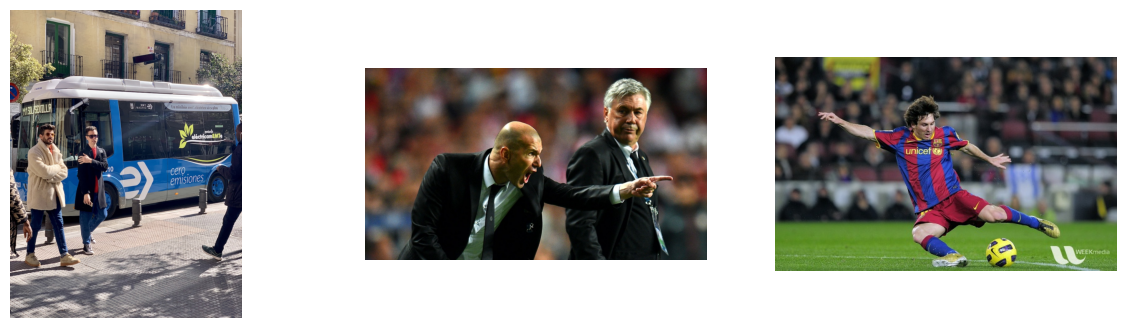

In [ ]:
images = load_images(IMAGE_URLS)
fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 4), squeeze=False)
for ax, im in zip(axes[0], images):
    ax.imshow(im); ax.axis("off")
plt.show()

## 5. Download from the bucket
- `onnx/model_int8.onnx` (+ `model_uint8.onnx`) — the bucket's INT8 files. They are *dynamically* quantized and are only used for a diagnosis in section 6
- `onnx/model.onnx` — FP32 source used to build the INT8 TFLite / NCNN models and as the accuracy reference

If the bucket URL fails, files are fetched from `Xenova/movenet-multipose-lightning` (same files).

In [ ]:
import onnx
import onnxruntime as ort


def _download(url: str, dst: Path) -> None:
    headers = {"User-Agent": "Mozilla/5.0"}
    if HF_TOKEN:
        headers["Authorization"] = f"Bearer {HF_TOKEN}"
    with requests.get(url, stream=True, timeout=120, headers=headers, allow_redirects=True) as r:
        r.raise_for_status()
        with open(dst, "wb") as f:
            for chunk in r.iter_content(1 << 20):
                f.write(chunk)


def get_onnx(fname: str) -> Path:
    dst = MODELS / fname
    if dst.exists() and dst.stat().st_size > 1000:
        return dst
    try:
        _download(f"{BUCKET_BASE}/{fname}?download=true", dst)
        onnx.load(str(dst))                       # validates it is a real ONNX file (not an HTML error page)
        print(f"Downloaded from bucket: {dst} ({dst.stat().st_size/1e6:.1f} MB)")
    except Exception as e:
        print(f"Bucket download of {fname} failed ({type(e).__name__}: {e}); trying Xenova/movenet-multipose-lightning")
        from huggingface_hub import hf_hub_download
        p = hf_hub_download("Xenova/movenet-multipose-lightning", f"onnx/{fname}",
                            local_dir=str(MODELS / "hf"), token=HF_TOKEN)
        shutil.copy(p, dst)
        print("Downloaded from HF repo:", dst)
    return dst


ONNX_FP32 = get_onnx("model.onnx")
ONNX_INT8 = get_onnx("model_int8.onnx")            # bucket INT8 (ONNX-Runtime dynamic quantization)
try:
    ONNX_UINT8 = get_onnx("model_uint8.onnx")
except Exception as e:
    ONNX_UINT8 = None
    print("model_uint8.onnx not available:", e)

for p in [q for q in (ONNX_FP32, ONNX_INT8, ONNX_UINT8) if q]:
    s = ort.InferenceSession(str(p), providers=["CPUExecutionProvider"])
    print(f"\n{p.name}  ({p.stat().st_size/1e6:.2f} MB)")
    print("  inputs :", [(i.name, i.type, i.shape) for i in s.get_inputs()])
    print("  outputs:", [(o.name, o.type, o.shape) for o in s.get_outputs()])
    print("  ops    :", sorted({n.op_type for n in onnx.load(str(p)).graph.node}))

Downloaded from bucket: movenet_work/models/model.onnx (19.0 MB)
Downloaded from bucket: movenet_work/models/model_int8.onnx (5.3 MB)
Downloaded from bucket: movenet_work/models/model_uint8.onnx (5.3 MB)

model.onnx  (19.05 MB)
  inputs : [('input', 'tensor(int32)', [1, 'unk__1502', 'unk__1503', 3])]
  outputs: [('output_0', 'tensor(float)', [1, 6, 56])]
  ops    : ['Abs', 'Add', 'And', 'ArgMax', 'BatchNormalization', 'Cast', 'Clip', 'Concat', 'Conv', 'Div', 'Equal', 'Exp', 'Expand', 'Gather', 'GatherND', 'Greater', 'Less', 'Max', 'MaxPool', 'Min', 'Mul', 'Not', 'Pow', 'Range', 'Reciprocal', 'ReduceMax', 'ReduceSum', 'Relu', 'Reshape', 'Resize', 'Shape', 'Sigmoid', 'Size', 'Slice', 'Split', 'Squeeze', 'Sub', 'Tile', 'TopK', 'Transpose', 'Unsqueeze']

model_int8.onnx  (5.26 MB)
  inputs : [('input', 'tensor(int32)', [1, 'unk__1502', 'unk__1503', 3])]
  outputs: [('output_0', 'tensor(float)', [1, 6, 56])]
  ops    : ['Abs', 'Add', 'And', 'ArgMax', 'BatchNormalization', 'Cast', 'Clip', 'C

## 6. Baseline: ONNX FP32, plus a diagnosis of the bucket's INT8 file
The bucket's `model_int8.onnx` is **dynamically quantized** (`ConvInteger` / `MatMulInteger`). For pose models this wrecks the heatmap/regression heads (person scores collapse towards 0) and is also very slow on CPU. It is therefore *not* used as a baseline or as a conversion source. The cell below proves it on your first image. The real INT8 models are built in sections 8-10 with calibration.

[ONNX FP32] image 0: 3 person(s), 107.9 ms
[ONNX FP32] image 1: 2 person(s), 98.5 ms
[ONNX FP32] image 2: 1 person(s), 99.7 ms
ONNX FP32                    best person score = 0.528   persons >= 0.25: 3   101 ms
bucket model_int8.onnx       best person score = 0.000   persons >= 0.25: 0   1262 ms
bucket model_uint8.onnx      best person score = 0.012   persons >= 0.25: 0   351 ms


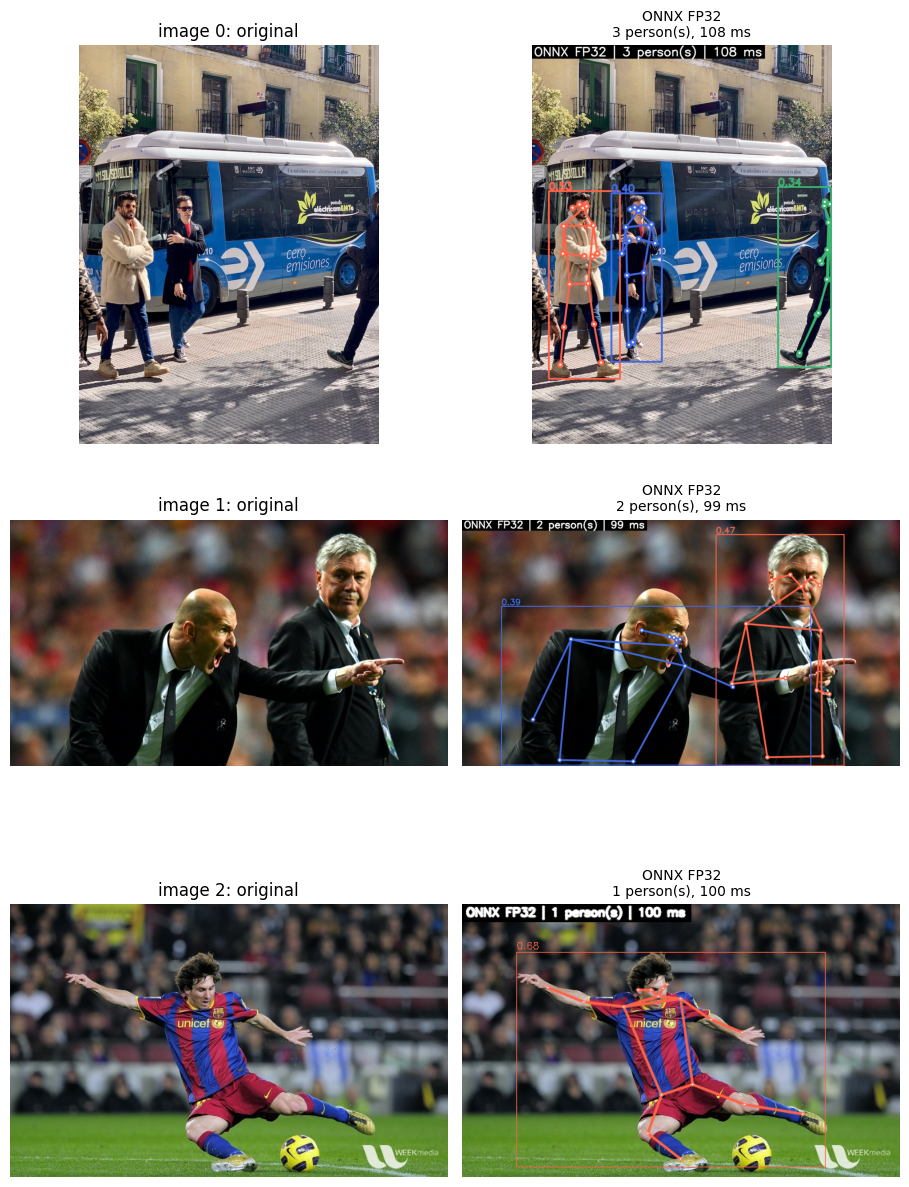

In [ ]:
_NP_DTYPE = {"tensor(int32)": np.int32, "tensor(float)": np.float32, "tensor(uint8)": np.uint8,
             "tensor(int64)": np.int64, "tensor(float16)": np.float16}


class OnnxRunner:
    """Accepts NHWC float input; transposes / casts to whatever the ONNX model wants."""
    def __init__(self, path: Path) -> None:
        self.sess = ort.InferenceSession(str(path), providers=["CPUExecutionProvider"])
        self.inp = self.sess.get_inputs()[0]
        self.dtype = _NP_DTYPE.get(self.inp.type, np.float32)
        s = self.inp.shape
        self.nchw = isinstance(s[1], int) and s[1] == 3 and s[-1] != 3

    def infer(self, x: np.ndarray) -> np.ndarray:
        if self.nchw:
            x = x.transpose(0, 3, 1, 2)
        return self.sess.run(None, {self.inp.name: np.ascontiguousarray(x).astype(self.dtype)})[0]


RESULTS: dict[str, list[Result]] = {}
RESULTS["ONNX FP32"] = run_backend("ONNX FP32", OnnxRunner(ONNX_FP32), images)
FP32_COUNTS: list[int] = [len(r.poses) for r in RESULTS["ONNX FP32"]]


def diagnose(label: str, path: Optional[Path]) -> None:
    if path is None:
        return
    runner = OnnxRunner(path)
    padded, info = letterbox(images[0], INPUT_SIZE)
    t0 = time.perf_counter()
    raw = np.asarray(runner.infer(padded[None].astype(np.float32))).reshape(-1, 56)
    ms = (time.perf_counter() - t0) * 1000
    print(f"{label:<28} best person score = {raw[:, 55].max():.3f}   persons >= {SCORE_THRESH}: "
          f"{int((raw[:, 55] >= SCORE_THRESH).sum())}   {ms:.0f} ms")


diagnose("ONNX FP32", ONNX_FP32)
diagnose("bucket model_int8.onnx", ONNX_INT8)
diagnose("bucket model_uint8.onnx", ONNX_UINT8)
show_grid(RESULTS, images)

## 7. Make the FP32 ONNX conversion-friendly
The original input is dynamic `(1, H, W, 3)` **int32**. Converters need a fixed shape and float input, so I replace it with a static **NCHW float32 `(1, 3, 256, 256)`** input (image-style, which `ncnn2table` and `onnx2tf` both handle natively) followed by a transpose back to the layout the graph expects. Values are identical; the check below proves it.

In [ ]:
from onnx import TensorProto, helper
from onnxsim import simplify

ONNX_FIXED = MODELS / "movenet_fixed_nchw.onnx"


def make_static_nchw_float_onnx(src: Path, dst: Path, size: int) -> str:
    model = onnx.load(str(src))
    init_names = {i.name for i in model.graph.initializer}
    old = [i for i in model.graph.input if i.name not in init_names][0]
    old_name = old.name
    used = {t for n in model.graph.node for t in list(n.input) + list(n.output)} | {i.name for i in model.graph.initializer}
    new_name = "images"
    while new_name in used:                       # never collide with an existing tensor name
        new_name += "_"
    print(f"replacing input '{old_name}' with static float '{new_name}' (1,3,{size},{size})")
    model.graph.input.remove(old)
    model.graph.input.insert(0, helper.make_tensor_value_info(new_name, TensorProto.FLOAT, [1, 3, size, size]))
    model.graph.node.insert(0, helper.make_node("Transpose", [new_name], [old_name], perm=[0, 2, 3, 1], name="nchw_to_nhwc_input"))
    del model.graph.value_info[:]
    try:
        simp, ok = simplify(model)
        model = simp if ok else model
        print("onnxsim:", "applied" if ok else "check failed, using unsimplified graph")
    except Exception as e:
        print("onnxsim skipped:", type(e).__name__, e)
    onnx.save(model, str(dst))
    return new_name


INPUT_NAME = make_static_nchw_float_onnx(ONNX_FP32, ONNX_FIXED, INPUT_SIZE)

_ref, _ = letterbox(images[0], INPUT_SIZE)
REF_X = _ref[None].astype(np.float32)                      # NHWC, 0..255
REF_FP32 = OnnxRunner(ONNX_FIXED).infer(REF_X)             # accuracy reference for all INT8 models
compare_raw(OnnxRunner(ONNX_FP32).infer(REF_X), REF_FP32, "ONNX FP32 original vs fixed")

replacing input 'input' with static float 'images' (1,3,256,256)
onnxsim: applied
[check] ONNX FP32 original vs fixed: max|diff| = 0.00000  (OK, tol 0.05)


1.1920928955078125e-06

## 8. Calibration set + quality check
Calibration samples are built from your images plus random flips / crops / brightness changes. For a production-quality INT8 model, replace them with 100-500 real images from your target domain.

`quality()` compares an INT8 runner with FP32: the number of detected people per image must match, and the raw output difference must be small. Sections 8b and 10 use it to pick the best INT8 variant automatically.

In [ ]:
def augment(img: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    h, w = img.shape[:2]
    s = rng.uniform(0.6, 1.0)
    ch, cw = max(32, int(h * s)), max(32, int(w * s))
    y0, x0 = rng.integers(0, h - ch + 1), rng.integers(0, w - cw + 1)
    out = img[y0:y0 + ch, x0:x0 + cw]
    if rng.random() < 0.5:
        out = out[:, ::-1]
    out = out.astype(np.float32) * rng.uniform(0.8, 1.2) + rng.uniform(-15, 15)
    return np.clip(out, 0, 255).astype(np.uint8)


def build_calibration(imgs: Sequence[np.ndarray], n: int, size: int, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    samples = []
    for i in range(n):
        base = imgs[i % len(imgs)]
        src = base if i < len(imgs) else augment(base, rng)
        samples.append(letterbox(src, size)[0])
    return np.stack(samples)                                     # (n, size, size, 3) uint8 RGB


CALIB = build_calibration(images, N_CALIB, INPUT_SIZE)
CALIB_DIR = WORK / "calib"
shutil.rmtree(CALIB_DIR, ignore_errors=True); CALIB_DIR.mkdir(parents=True)

CALIB_NPY = CALIB_DIR / "calib_nhwc_0_1.npy"                    # for onnx2tf: NHWC float 0..1
np.save(CALIB_NPY, (CALIB.astype(np.float32) / 255.0))

imglist = []                                                     # for ncnn2table: image files + list
for i, c in enumerate(CALIB):
    p = (CALIB_DIR / f"calib_{i:03d}.png").resolve()
    cv2.imwrite(str(p), cv2.cvtColor(c, cv2.COLOR_RGB2BGR))
    imglist.append(str(p))
CALIB_LIST = CALIB_DIR / "imagelist.txt"
CALIB_LIST.write_text("\n".join(imglist) + "\n")
print(f"{len(CALIB)} calibration samples -> {CALIB_DIR}")


def quality(runner: PoseRunner) -> tuple[tuple[int, float], list[int]]:
    """Returns ((count_mismatch, raw_diff), counts). (0, <0.15) means 'matches FP32'."""
    counts = []
    for img in images:
        padded, info = letterbox(img, INPUT_SIZE)
        counts.append(len(decode_output(runner.infer(padded[None].astype(np.float32)), info, SCORE_THRESH)))
    mismatch = int(sum(abs(c - f) for c, f in zip(counts, FP32_COUNTS)))
    a = np.asarray(runner.infer(REF_X), np.float32).reshape(-1)
    diff = float(np.abs(a - np.asarray(REF_FP32, np.float32).reshape(-1)).max())
    return (mismatch, diff), counts


def is_good(score: tuple[int, float]) -> bool:
    return score[0] == 0 and score[1] < 0.15

48 calibration samples -> movenet_work/calib


## 9. ONNX → LiteRT / TFLite: **INT8** and **FP16** (`onnx2tf`)
`onnx2tf` writes several variants in one run. I keep:
- **INT8**: the most-INT8 variant that matches FP32 (full-integer first, then integer, then dynamic-range as a last resort)
- **FP16**: `*_float16.tflite` (FP16 weights, float32 inputs/outputs)

These contain the whole model including the post-processing, so the output is directly `(1, 6, 56)`.

In [ ]:
def _run(cmd: list[str], cwd: Optional[Path] = None) -> subprocess.CompletedProcess:
    return subprocess.run(cmd, cwd=cwd, capture_output=True, text=True)


def _dequant(t: np.ndarray, q: tuple[float, int]) -> np.ndarray:
    scale, zp = q
    if t.dtype in (np.int8, np.uint8, np.int16) and scale > 0:
        return (t.astype(np.float32) - zp) * scale
    return t.astype(np.float32)


class TFLiteRunner:
    def __init__(self, path: Path, verbose: bool = True) -> None:
        try:
            from ai_edge_litert.interpreter import Interpreter
        except ImportError:
            import tensorflow as tf
            Interpreter = tf.lite.Interpreter
        self.interp = Interpreter(model_path=str(path))
        self.interp.allocate_tensors()
        self.inp = self.interp.get_input_details()[0]
        self.outs = self.interp.get_output_details()
        if verbose:
            print(f"  {Path(path).name}: input {tuple(int(v) for v in self.inp['shape'])} {np.dtype(self.inp['dtype']).name} "
                  f"q={tuple(self.inp['quantization'])}; outputs " +
                  ", ".join(f"{tuple(int(v) for v in o['shape'])} {np.dtype(o['dtype']).name}" for o in self.outs))

    def infer(self, x: np.ndarray) -> np.ndarray:
        shape = tuple(int(s) for s in self.inp["shape"])
        data = x
        if shape != data.shape:
            if len(shape) == 4 and shape[1] == 3 and shape[-1] != 3:      # model wants NCHW
                data = data.transpose(0, 3, 1, 2)
            else:
                self.interp.resize_tensor_input(self.inp["index"], list(data.shape))
                self.interp.allocate_tensors()
                self.inp = self.interp.get_input_details()[0]
        dt = np.dtype(self.inp["dtype"])
        scale, zp = self.inp["quantization"]
        if dt.kind in "iu" and scale > 0:                                  # quantize float input -> int8/uint8
            info = np.iinfo(dt)
            data = np.clip(np.round(data / scale + zp), info.min, info.max)
        self.interp.set_tensor(self.inp["index"], np.ascontiguousarray(data).astype(dt))
        self.interp.invoke()
        outs = [_dequant(self.interp.get_tensor(o["index"]), o["quantization"]) for o in self.outs]
        cands = [o for o in outs if o.size >= 336 and o.size % 56 == 0]
        return (cands or outs)[0]


def convert_to_tflite(onnx_path: Path, out_dir: Path, input_name: str, calib_npy: Path) -> dict[str, Path]:
    """Returns {'int8': path, 'fp16': path} for whatever succeeded."""
    exe = shutil.which("onnx2tf")
    base = [exe] if exe else [sys.executable, "-m", "onnx2tf"]
    # calib data is 0..1 -> (v - 0) / (1/255) = 0..255, the range the model expects
    common = ["-i", str(onnx_path), "-o", str(out_dir), "-oiqt",
              "-cind", input_name, str(calib_npy), "[[[[0.0]]]]", "[[[[0.00392156862745098]]]]",
              "-iqd", "int8", "-oqd", "float32"]
    ok = False
    for extra in (["-tb", "tf_converter"], []):         # tf_converter backend quantizes best; retry w/o flag
        shutil.rmtree(out_dir, ignore_errors=True)
        cmd = base + common + extra
        print("running:", " ".join(cmd))
        p = _run(cmd)
        if p.returncode == 0 and list(out_dir.glob("*.tflite")):
            ok = True
            break
        print("  failed. Last log lines:\n" + "\n".join((p.stdout + p.stderr).strip().splitlines()[-15:]))
    result: dict[str, Path] = {}
    if not ok:
        return result

    # ---- FP16 ----
    for f in sorted(out_dir.glob("*_float16.tflite")):
        try:
            score, counts = quality(TFLiteRunner(f))
        except Exception as e:
            print(f"  {f.name}: cannot run ({type(e).__name__}: {e})"); continue
        print(f"  float16: persons {counts} vs FP32 {FP32_COUNTS}, mismatch={score[0]}, max|diff|={score[1]:.4f}")
        dst = MODELS / "movenet_multipose_lightning_fp16.tflite"
        shutil.copy(f, dst); result["fp16"] = dst
        break
    else:
        print("  (no *_float16.tflite produced)")

    # ---- INT8 ----
    best: Optional[tuple[tuple[int, float], Path, str]] = None
    for pref in ["full_integer_quant", "integer_quant", "dynamic_range_quant"]:
        files = sorted(out_dir.glob(f"*_{pref}.tflite"))
        if pref == "integer_quant":
            files = [f for f in files if "full_integer_quant" not in f.name]
        for f in files:
            if "int16" in f.name:
                continue
            try:
                score, counts = quality(TFLiteRunner(f))
            except Exception as e:
                print(f"  {f.name}: cannot run ({type(e).__name__}: {e})"); continue
            print(f"  {pref}: persons {counts} vs FP32 {FP32_COUNTS}, mismatch={score[0]}, max|diff|={score[1]:.4f}")
            if best is None or score < best[0]:
                best = (score, f, pref)
            if is_good(score):
                best = (score, f, pref)
                break
        if best is not None and is_good(best[0]):
            break
    if best is not None:
        dst = MODELS / "movenet_multipose_lightning_int8.tflite"
        shutil.copy(best[1], dst); result["int8"] = dst
        print(f"INT8 -> {dst.name} [{best[2]}]", "(matches FP32)" if is_good(best[0]) else "(WARNING: differs from FP32 - see notes at the end)")
    return result


TFLITE_INT8: Optional[Path] = None
TFLITE_FP16: Optional[Path] = None
try:
    _tfl = convert_to_tflite(ONNX_FIXED, WORK / "tflite_build", INPUT_NAME, CALIB_NPY)
    TFLITE_INT8, TFLITE_FP16 = _tfl.get("int8"), _tfl.get("fp16")
except Exception as e:
    print("TFLite conversion error:", type(e).__name__, e)
for _n, _p in (("INT8", TFLITE_INT8), ("FP16", TFLITE_FP16)):
    print(f"TFLite {_n}:", _p if _p else "NOT produced - see log above")

running: /usr/local/bin/onnx2tf -i movenet_work/models/movenet_fixed_nchw.onnx -o movenet_work/tflite_build -oiqt -cind images movenet_work/calib/calib_nhwc_0_1.npy [[[[0.0]]]] [[[[0.00392156862745098]]]] -iqd int8 -oqd float32 -tb tf_converter
  movenet_fixed_nchw_float16.tflite: input (1, 256, 256, 3) float32 q=(0.0, 0); outputs (1, 6, 56) float32
  float16: persons [3, 2, 1] vs FP32 [3, 2, 1], mismatch=0, max|diff|=0.6013
  movenet_fixed_nchw_full_integer_quant.tflite: input (1, 256, 256, 3) int8 q=(0.9999999403953552, -128); outputs (1, 6, 56) float32
  full_integer_quant: persons [0, 0, 0] vs FP32 [3, 2, 1], mismatch=6, max|diff|=0.8131
  movenet_fixed_nchw_integer_quant.tflite: input (1, 256, 256, 3) float32 q=(0.0, 0); outputs (1, 6, 56) float32
  integer_quant: persons [0, 0, 0] vs FP32 [3, 2, 1], mismatch=6, max|diff|=0.8131
  movenet_fixed_nchw_dynamic_range_quant.tflite: input (1, 256, 256, 3) float32 q=(0.0, 0); outputs (1, 6, 56) float32
  dynamic_range_quant: persons [3, 

## 10. ONNX → NCNN **FP16** (automatic split: backbone in NCNN, post-processing separate)
The model's built-in post-processing uses ops NCNN does not have (`pnnx` turns them into `torch.lt` & co., which NCNN cannot load). So:

1. Walk the graph from the input and keep every node whose op NCNN supports → **backbone** (all the convolutions)
2. The first unsupported op marks the cut. Everything after it is the **tail** (`tail.onnx`, the exact original post-processing)
3. Only the backbone goes through `pnnx` (`fp16=1` → FP16 weights)
4. `backbone ∘ tail` is verified to equal the full model before anything is converted

In [ ]:
import onnx.utils

SAFE_OPS = {"Conv", "Relu", "Clip", "Sigmoid", "Add", "Sub", "Mul", "Div", "Transpose", "Reshape", "Concat",
            "Resize", "MaxPool", "AveragePool", "GlobalAveragePool", "Pad", "BatchNormalization", "HardSwish",
            "LeakyRelu", "Identity", "ConvTranspose", "Squeeze", "Unsqueeze"}


@dataclass
class SplitInfo:
    input_name: str
    backbone: Path
    tail: Path
    bb_outputs: list[str]        # tensors the backbone returns (= tail inputs)
    tail_needs_input: bool       # tail also reads the image tensor directly
    blockers: list[str]          # op types where the graph was cut
    n_prefix: int
    n_conv: int


def split_graph(model: onnx.ModelProto, whitelist: set[str]):
    g = model.graph
    init = {i.name for i in g.initializer}
    static = set(init)                                   # tensors that do not depend on the image
    for n in g.node:
        if all((i == "" or i in static) for i in n.input):
            static.update(n.output)
    inp = [i.name for i in g.input if i.name not in init][0]
    avail, prefix = {inp}, set()
    for idx, n in enumerate(g.node):
        dyn = [i for i in n.input if i and i not in static]
        if n.op_type in whitelist and dyn and all(i in avail for i in dyn):
            prefix.add(idx); avail.update(n.output)
    frontier: list[str] = []
    for idx, n in enumerate(g.node):
        if idx in prefix:
            continue
        for i in n.input:
            if i in avail and i not in frontier:
                frontier.append(i)
    for o in g.output:
        if o.name in avail and o.name not in frontier:
            frontier.append(o.name)
    blockers = sorted({g.node[i].op_type for i in range(len(g.node))
                       if i not in prefix and any(x in avail for x in g.node[i].input)})
    return inp, prefix, frontier, blockers


def split_for_ncnn(onnx_path: Path, out_dir: Path) -> SplitInfo:
    shutil.rmtree(out_dir, ignore_errors=True); out_dir.mkdir(parents=True)
    model = onnx.load(str(onnx_path))
    inp, prefix, frontier, blockers = split_graph(model, SAFE_OPS)
    n_conv = sum(model.graph.node[i].op_type == "Conv" for i in prefix)
    print(f"backbone: {len(prefix)} nodes ({n_conv} Conv) | cut tensors: {frontier} | first unsupported ops: {blockers}")
    if n_conv < 3:
        raise RuntimeError(f"Only {n_conv} Conv layers before the first unsupported op {blockers}; cannot split sensibly.")
    bb_out = [f for f in frontier if f != inp]
    bb, tail = out_dir / "backbone.onnx", out_dir / "tail.onnx"
    onnx.utils.extract_model(str(onnx_path), str(bb), [inp], bb_out)
    onnx.utils.extract_model(str(onnx_path), str(tail), frontier, [o.name for o in model.graph.output])

    # verify backbone -> tail == full model
    x = REF_X.transpose(0, 3, 1, 2)
    feeds = dict(zip(bb_out, ort.InferenceSession(str(bb), providers=["CPUExecutionProvider"]).run(None, {inp: x})))
    if inp in frontier:
        feeds[inp] = x
    out = ort.InferenceSession(str(tail), providers=["CPUExecutionProvider"]).run(None, feeds)[0]
    compare_raw(REF_FP32, out, "split (backbone -> tail) vs full ONNX", tol=1e-3)

    (out_dir / "tail_nodes.txt").write_text("\n".join(onnx.helper.printable_node(n) for n in onnx.load(str(tail)).graph.node))
    ops = sorted({n.op_type for n in onnx.load(str(tail)).graph.node})
    print(f"tail: {len(onnx.load(str(tail)).graph.node)} nodes, ops: {ops}  (full listing: {out_dir / 'tail_nodes.txt'})")
    return SplitInfo(inp, bb, tail, bb_out, inp in frontier, blockers, len(prefix), n_conv)


def find_pnnx() -> str:
    exe = shutil.which("pnnx")
    if not exe:
        raise RuntimeError("pnnx not found - run the install cell (pip install pnnx).")
    return exe


def convert_backbone_to_ncnn_fp16(split: SplitInfo, size: int) -> tuple[Path, Path]:
    out_dir = split.backbone.parent
    cmd = [find_pnnx(), split.backbone.name, f"inputshape=[1,3,{size},{size}]f32", "fp16=1"]
    print("pnnx:", " ".join(cmd))
    p = _run(cmd, out_dir)
    param, binf = out_dir / "backbone.ncnn.param", out_dir / "backbone.ncnn.bin"
    if p.returncode != 0 or not param.exists():
        raise RuntimeError("pnnx failed:\n" + "\n".join((p.stdout + p.stderr).strip().splitlines()[-25:]))
    bad = [l.split()[0] for l in param.read_text().splitlines()[2:] if l.split() and l.split()[0].startswith(("torch.", "aten::", "F.", "Tensor."))]
    if bad:
        raise RuntimeError(f"backbone still contains layers NCNN cannot run: {sorted(set(bad))}. "
                           f"Remove the matching op types from SAFE_OPS and re-run.")
    final_p, final_b = out_dir / "movenet_backbone_fp16.param", out_dir / "movenet_backbone_fp16.bin"
    shutil.copy(param, final_p); shutil.copy(binf, final_b)
    print(f"NCNN FP16 backbone: {final_p.name} ({final_p.stat().st_size/1e3:.0f} KB), {final_b.name} ({final_b.stat().st_size/1e6:.2f} MB)")
    return final_p, final_b


SPLIT: Optional[SplitInfo] = None
NCNN_PARAM: Optional[Path] = None
NCNN_BIN: Optional[Path] = None
try:
    SPLIT = split_for_ncnn(ONNX_FIXED, MODELS / "ncnn_fp16")
    NCNN_PARAM, NCNN_BIN = convert_backbone_to_ncnn_fp16(SPLIT, INPUT_SIZE)
except Exception as e:
    print("NCNN conversion error:", e)

backbone: 161 nodes (80 Conv) | cut tensors: ['Unsqueeze__961:0', 'StatefulPartitionedCall/sub_2:0', 'Squeeze__1496:0', 'StatefulPartitionedCall/kpt_regress_0/conv2d_8/BiasAdd__916:0', 'Transpose__1386:0', 'StatefulPartitionedCall/box_offset_0/conv2d_6/BiasAdd__1138:0', 'StatefulPartitionedCall/Reshape_8:0'] | first unsupported ops: ['Abs', 'GatherND', 'Mul', 'Slice']
[check] split (backbone -> tail) vs full ONNX: max|diff| = 0.00000  (OK, tol 0.001)
tail: 170 nodes, ops: ['Abs', 'Add', 'And', 'ArgMax', 'Cast', 'Concat', 'Div', 'Equal', 'Exp', 'GatherND', 'Greater', 'Less', 'Max', 'Min', 'Mul', 'Not', 'Pow', 'Reciprocal', 'ReduceMax', 'ReduceSum', 'Reshape', 'Slice', 'Split', 'Squeeze', 'Sub', 'Tile', 'TopK', 'Unsqueeze']  (full listing: movenet_work/models/ncnn_fp16/tail_nodes.txt)
pnnx: /usr/local/bin/pnnx backbone.onnx inputshape=[1,3,256,256]f32 fp16=1
NCNN FP16 backbone: movenet_backbone_fp16.param (13 KB), movenet_backbone_fp16.bin (9.50 MB)


## 11. Load the NCNN FP16 model
Runs the NCNN backbone, then the tail (post-processing). The cell first matches every NCNN output blob to the ONNX tensor it represents and prints the difference, so you can see that NCNN reproduces the backbone.

In [ ]:
import ncnn


class NcnnSplitRunner:
    """NCNN backbone (FP16 weights) + tail.onnx post-processing -> raw (1, 6, 56)."""

    def __init__(self, param: Path, binf: Path, split: SplitInfo, sample_nhwc: np.ndarray, threads: int = 2) -> None:
        self.net = ncnn.Net()
        o = self.net.opt
        o.use_vulkan_compute = False
        o.use_fp16_packed = o.use_fp16_storage = o.use_fp16_arithmetic = False   # FP16 *weights*, FP32 math (set True on phones that support it)
        o.use_bf16_storage = False
        o.num_threads = threads
        if self.net.load_param(str(param)) != 0 or self.net.load_model(str(binf)) != 0:
            raise RuntimeError("ncnn failed to load param/bin")
        self.in_name = self.net.input_names()[0]
        self.out_names = list(self.net.output_names())
        self.split = split
        prov = ["CPUExecutionProvider"]
        self.tail = ort.InferenceSession(str(split.tail), providers=prov)

        # bind ncnn output blobs <-> backbone ONNX tensors by comparing values on a sample
        bb = ort.InferenceSession(str(split.backbone), providers=prov)
        x = sample_nhwc.transpose(0, 3, 1, 2)
        ref = dict(zip(split.bb_outputs, bb.run(None, {split.input_name: x})))
        self.shapes = {k: v.shape for k, v in ref.items()}
        got = self._run_ncnn(x)
        self.bind: dict[str, str] = {}
        print("ncnn input:", self.in_name, "| output blobs:", self.out_names)
        for name, arr in ref.items():
            cands = [(float(np.abs(g - arr.reshape(-1)).max()) if g.size == arr.size else float("inf"), blob) for blob, g in got.items()]
            d, blob = min(cands)
            if not np.isfinite(d):
                raise RuntimeError(f"no ncnn blob has the size of backbone tensor '{name}' {arr.shape}")
            self.bind[name] = blob
            print(f"  backbone tensor '{name}' {arr.shape} <- ncnn '{blob}'  max|diff| = {d:.5f}")

    def _run_ncnn(self, x_nchw: np.ndarray) -> dict[str, np.ndarray]:
        arr = np.ascontiguousarray(x_nchw[0], dtype=np.float32)               # (3, H, W) = c, h, w
        outs: dict[str, np.ndarray] = {}
        with self.net.create_extractor() as ex:
            ex.input(self.in_name, ncnn.Mat(arr).clone())
            for name in self.out_names:
                _, m = ex.extract(name)
                outs[name] = np.array(m).reshape(-1)
        return outs

    def infer(self, x: np.ndarray) -> np.ndarray:
        x_nchw = x.transpose(0, 3, 1, 2)
        got = self._run_ncnn(x_nchw)
        feeds = {k: got[b].reshape(self.shapes[k]) for k, b in self.bind.items()}
        if self.split.tail_needs_input:
            feeds[self.split.input_name] = np.ascontiguousarray(x_nchw)
        return self.tail.run(None, feeds)[0]


NCNN_RUNNER: Optional[NcnnSplitRunner] = None
if NCNN_PARAM is not None and SPLIT is not None:
    try:
        NCNN_RUNNER = NcnnSplitRunner(NCNN_PARAM, NCNN_BIN, SPLIT, REF_X)
        score, counts = quality(NCNN_RUNNER)
        print(f"NCNN FP16: persons {counts} vs FP32 {FP32_COUNTS}, mismatch={score[0]}, max|diff|={score[1]:.4f}",
              "(matches FP32)" if is_good(score) else "(WARNING: differs from FP32)")
    except Exception as e:
        print("NCNN load/run error:", type(e).__name__, e)
else:
    print("NCNN model not available (conversion failed above).")

ncnn input: in0 | output blobs: ['out4', 'out5', 'out3', 'out6', 'out2', 'out0', 'out1']
  backbone tensor 'Unsqueeze__961:0' (64, 64, 1, 17) <- ncnn 'out0'  max|diff| = 0.80374
  backbone tensor 'StatefulPartitionedCall/sub_2:0' (1, 1, 64, 64) <- ncnn 'out1'  max|diff| = 0.11578
  backbone tensor 'Squeeze__1496:0' (1, 64, 64, 1) <- ncnn 'out2'  max|diff| = 0.15747
  backbone tensor 'StatefulPartitionedCall/kpt_regress_0/conv2d_8/BiasAdd__916:0' (64, 64, 34) <- ncnn 'out3'  max|diff| = 20.74158
  backbone tensor 'Transpose__1386:0' (1, 64, 64, 2) <- ncnn 'out4'  max|diff| = 12.43756
  backbone tensor 'StatefulPartitionedCall/box_offset_0/conv2d_6/BiasAdd__1138:0' (1, 64, 64, 2) <- ncnn 'out5'  max|diff| = 1.21828
  backbone tensor 'StatefulPartitionedCall/Reshape_8:0' (64, 64, 17, 2) <- ncnn 'out6'  max|diff| = 6.19714
NCNN FP16: persons [2, 2, 1] vs FP32 [3, 2, 1], mismatch=1, max|diff|=0.7543 (WARNING: differs from FP32)


## 12. Test the converted models again → annotate → visualize

[TFLite INT8] image 0: 3 person(s), 191.5 ms
[TFLite INT8] image 1: 2 person(s), 248.0 ms
[TFLite INT8] image 2: 1 person(s), 82.6 ms
[TFLite FP16] image 0: 3 person(s), 47.0 ms
[TFLite FP16] image 1: 2 person(s), 46.1 ms
[TFLite FP16] image 2: 1 person(s), 44.8 ms
[NCNN FP16] image 0: 2 person(s), 74.9 ms
[NCNN FP16] image 1: 2 person(s), 93.1 ms
[NCNN FP16] image 2: 1 person(s), 66.3 ms


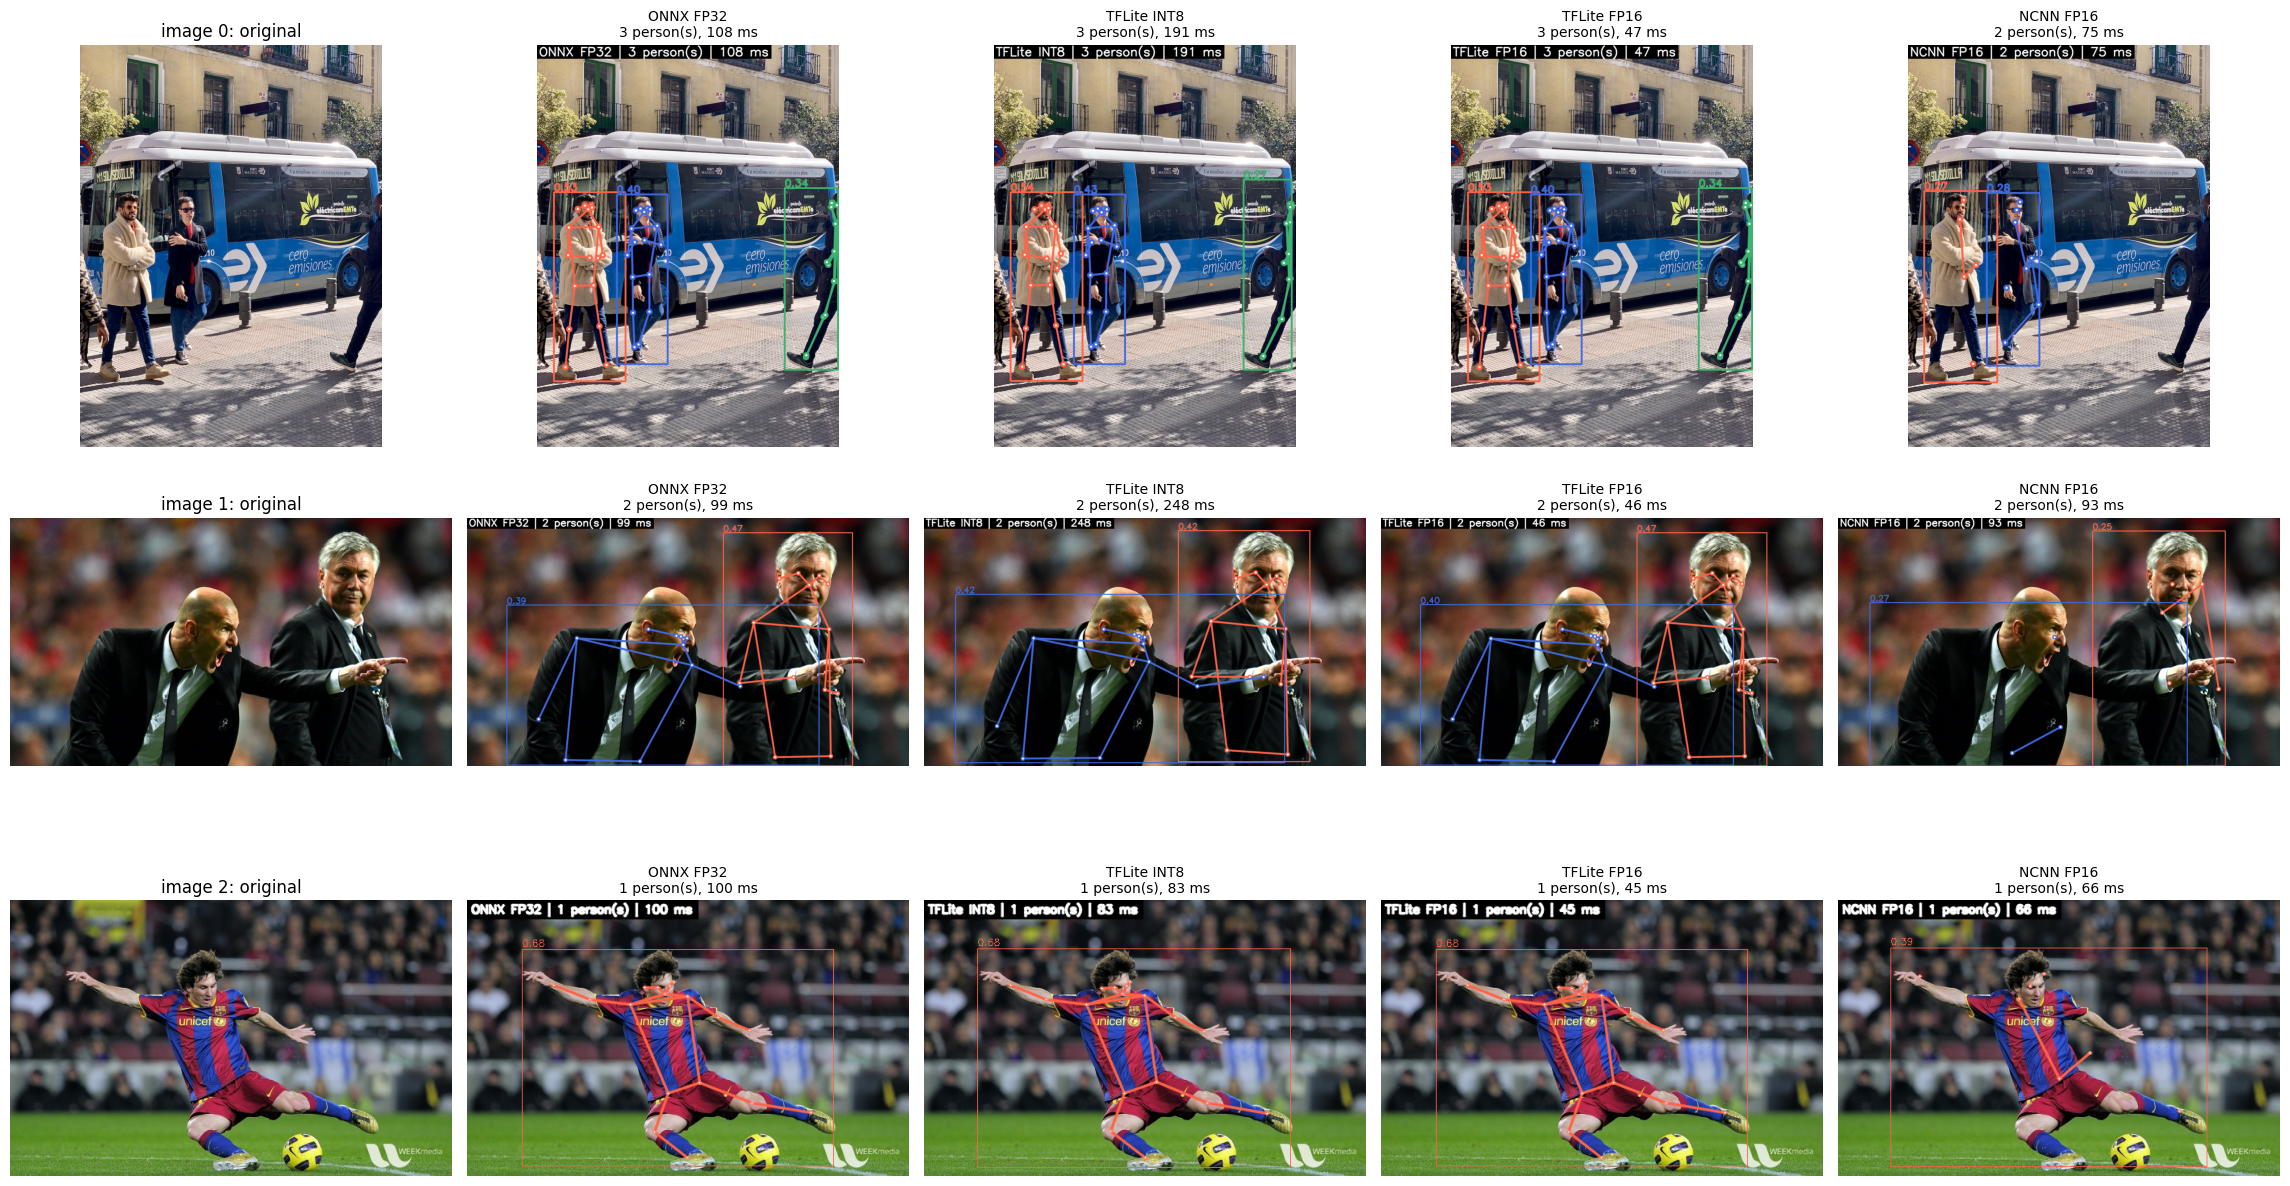


backend             avg ms       persons per image
ONNX FP32            102.0               [3, 2, 1]
TFLite INT8          174.0               [3, 2, 1]
TFLite FP16           46.0               [3, 2, 1]
NCNN FP16             78.1               [2, 2, 1]

Annotated images saved in: /content/movenet_work/outputs


In [ ]:
if TFLITE_INT8 is not None:
    RESULTS["TFLite INT8"] = run_backend("TFLite INT8", TFLiteRunner(TFLITE_INT8, verbose=False), images)
if TFLITE_FP16 is not None:
    RESULTS["TFLite FP16"] = run_backend("TFLite FP16", TFLiteRunner(TFLITE_FP16, verbose=False), images)
if NCNN_RUNNER is not None:
    RESULTS["NCNN FP16"] = run_backend("NCNN FP16", NCNN_RUNNER, images)

show_grid(RESULTS, images)

print(f"\n{'backend':<16}{'avg ms':>10}{'persons per image':>24}")
for name, res in RESULTS.items():
    print(f"{name:<16}{np.mean([r.latency_ms for r in res]):>10.1f}{str([len(r.poses) for r in res]):>24}")
print("\nAnnotated images saved in:", OUT.resolve())

## 13. Save / download the models

In [ ]:
import json

bundle = WORK / "export"
shutil.rmtree(bundle, ignore_errors=True); bundle.mkdir(parents=True)
exports: list[Path] = [p for p in [TFLITE_INT8, TFLITE_FP16, NCNN_PARAM, NCNN_BIN] if p and Path(p).exists()]
if SPLIT is not None:
    exports += [SPLIT.tail, SPLIT.tail.parent / "tail_nodes.txt"]
    (bundle / "ncnn_split_info.json").write_text(json.dumps({
        "ncnn_input_blob": NCNN_RUNNER.in_name if NCNN_RUNNER else None,
        "ncnn_input": "RGB float 0..255, CHW 3x256x256, no mean/norm",
        "ncnn_output_blobs": {k: {"blob": NCNN_RUNNER.bind[k], "shape": list(NCNN_RUNNER.shapes[k])} for k in NCNN_RUNNER.bind} if NCNN_RUNNER else {},
        "tail_onnx": "tail.onnx takes those tensors (by name) and returns (1, 6, 56)",
        "first_unsupported_ops": SPLIT.blockers,
    }, indent=2))
for p in exports:
    shutil.copy(p, bundle / Path(p).name)
for p in sorted(bundle.iterdir()):
    print(f"{p.name:<40}{p.stat().st_size/1e6:>8.3f} MB")
try:  # works only inside Colab
    from google.colab import files
    files.download(shutil.make_archive("movenet_models", "zip", bundle))
except Exception:
    print("Not running in Colab; files are in", bundle.resolve())

movenet_backbone_fp16.bin                  9.499 MB
movenet_backbone_fp16.param                0.013 MB
movenet_multipose_lightning_fp16.tflite    9.547 MB
movenet_multipose_lightning_int8.tflite    5.229 MB
ncnn_split_info.json                       0.001 MB
tail.onnx                                  0.105 MB
tail_nodes.txt                             0.020 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Notes
- **LiteRT / TFLite (`…_int8.tflite`, `…_fp16.tflite`)**: complete models, output is `(1, 6, 56)`. Easiest to use on mobile. INT8 input scale / zero-point are read from the model by the runner.
- **NCNN FP16**: `movenet_backbone_fp16.param/.bin` is the **backbone only**. The post-processing is `tail.onnx` (exact original ops; `tail_nodes.txt` lists them one per line, `ncnn_split_info.json` lists the tensors that go from NCNN into the tail). On a phone you must re-implement that tail in C++/Kotlin, or use the TFLite model instead.
- NCNN input: RGB float 0..255, CHW `3×256×256` (`Mat::from_pixels_resize` with `PIXEL_RGB`, no mean/norm). To use FP16 math at runtime on ARM set `use_fp16_packed/storage/arithmetic = true`.
- **If "WARNING: differs from FP32"** on TFLite INT8: use more / more varied calibration images (`N_CALIB`, real photos with people); the TFLite FP16 file is the safe fallback.
- Padding is added at bottom/right, so mapping back to the original image is `coord_norm * 256 / scale`.